---
Tracking Unit Conversions in Python
---

#**Abstract**

This main goal of this tutorial aims to explain how to use astropy.units and will later give an example of converting flux to Star Formation Rate while using such units. However, I digress occasionally and delve into the basics of FITS files, reading in an SED file, and even how to incorporate a slider into your graphs. Firstly, I will run through some relatively simple conversions involving units of wavelength. Afterwards, I will introduce how to convert between more complicated sets of units such as Janskys, Fλ, and Fν. Lastly, I will show examples calculating the Luminosity from Flux Density, and subsequently the Star Formation Rate using the IR and UV Kennicutt 2012 paper's conversions. Hopefully this tutorial helps with any confusion or gives some much needed clarification. Check out the astropy.units page as well for the whole list of units available:

https://docs.astropy.org/en/stable/units/#module-astropy.units

#**Introduction**

Astropy.units is a wonderful tool that makes calculations and conversions 100% easier. Beforehand, it was always a constant headache to redefine conversion functions and keep track of the units throughout my code. The fear of missing one little units detail was also ever-present since plotting the data with incorrect units is never fun. With units being semi-permanently attached to values, I never have to worry about these issues now.

After the initial assignment of the units to a value, your code can do all the heavy lifting for you. When adding or subtracting, Astropy.units checks to see if your units are consistent. Meanwhile, multiplying or dividing will cancel out or tack on units. In addition, one of the most useful functions (the "to" function) is added in this package. This function makes conversions so much easier since you can simply state what units you want, and you can consider it done.

As mentioned before, it can be quite cumbersome to define numerous functions based solely on conversions. This can span many lines of code and take a long time to set up. The whole premise of defining many conversion functions can become tedious with jumbled up factors, function names, and required inputs. Therefore, if you just import units from astropy, you will not have to worry about most conversion functions and can just focus on the main task.

Speaking on the units themselves, they will be right alongside their values after being assigned. When printing a variable, you will get the value and the associated units in a single line. This can be quite useful if your code is not working as intended as you can print after every line to watch values and units change. In addition, after some time away from your code, you may forgot what certain functions or lines actually compute. Therefore, seeing units paired with values in the console may help to jog your memory.

On another quick note, I find Janskys, Fν, and Fλ to be challenging to convert between and work with. Thus, you can merely just use the conversion function to tackle these units. So, if you have trouble with this as well, Astropy.units might be helpful for you.

Overall, astropy.units is a great tool for anyone. I would especially recommend it to any beginner astronomers learning to code in python, but realistically it can be helpful and applicable at any level.

>**Now Let's Jump Into It**

##Before you run any code be sure to make your own copy of this Google Colaboratory!

As always, import the packages you need, but this time add in your new best friend: astropy.units.

In [ ]:
# you should import the units as u so whenever you use it you can just type "u" instead of the whole "units" bit
from astropy import units as u

#from astropy.units import cds as cds  # other useful units are included in this module, but are not needed in this
                                       # tutorial, if you need to use c as a unit as in MeV/c, here it is

from astropy import visualization   # this is helpful in plotting, but not always necessary

from astropy.io import fits   # importing this will enable us to read in our fits files

from astropy.cosmology import FlatLambdaCDM   # super useful in assuming your cosmology

import numpy as np   # same here -- use as np.array() for shorthand

import scipy.constants as con   # this will be used for constants

import scipy.integrate as integrate   # needed in order to integrate over our SED

import matplotlib.pyplot as plt

from matplotlib.widgets import Slider   # module needed for using a slider with graphs

> **The Files You Need**

In order to run this code you will need both files (which were provided by Dr. Lamiya Mowla, so a big thank you to her!) from the google drive folder at the end of this paragraph. Once downloaded, go to the folder icon at the left part of the google colab screen. From there, click on the paper with an arrow on it directly under the "Files" title. Now, upload both documents you have downloaded. Everytime you open this tutorial after closing it, you will have to reupload the two files from the folder. Here are the files: [Click Here](https://drive.google.com/drive/folders/1s_vtuvXrdC4payI4NzYvRdkVxfj_H_L6?usp=sharing)

The files come from SIMBA, a cosmological simulation based around the evolution of galaxies ([SIMBA](http://simba.roe.ac.uk)). More specifically, the simulation combines hydrodynamics with other complex phenomena involved in galaxy formation to ensure accurate images similar to real observations. In the context of this tutorial, the files downloaded depict a high mass, star forming galaxy and will serve as the basis for our coding.

See also: [Davé et al. (2019)](https://arxiv.org/pdf/1901.10203.pdf)

> **The FITS Header**

After uploading the files, you will now be able to open the FITS file and can observe the galaxy itself with a wide range of information found in the header. Some of this information is crucial to what we will be doing. Try to figure out which rows correspond to the Star Formation Rate and what the numerous "IWAV#" labels mean in the context of our images. See if there are any other abbreviations you may recognize.

In [ ]:
image_file = open("m100n1024_snap078_72_allwav_ang0_dust.fits", mode='rb')
hdu_list = fits.open(image_file)
image_data = hdu_list[0].data
hdu_list[0].header

You may notice the file is a ".fits" and if you have never seen this before it can be unfamiliar and strange. FITS stands for Flexible Image Transport System and the concept is that you have the images themselves as their own two dimensions (i.e. x and y coordinates). Then, you can add a third dimension based on whatever you are measuring. In the example here, we are measuring the flux or the light we see from the galaxy at specific wavelengths, called the "flux density." I will go into more detail on that later when we are dealing with those units, but for the moment we should appreciate how much information is given in this one header. In fact, in other more complicated data sets, you can have more than 3 dimensions and much more information in the header.

Within the rest of the FITS header, we have a lot of other helpful and relevant information about the file itself. Most of the rows provide a little description of what the value is or represents. Starting with the top, NAXIS1 and NAXIS2 give the dimensions of the images, so they are 499 pixels by 499 pixels. Meanwhile, NAXIS3 tells you how many images are present in which we have measured the flux at specific wavelengths. You can think of the FITS file like a cube, the length and height are the image dimensions, and the width is the data of the images themselves.

![picture](https://drive.google.com/uc?export=view&id=1rxhVrrmiVa4wu-cquSxbJdeoQ-efbmso)
Other useful values are LMSTAR, LMGAS, and LMDUST which are the logarithms of the stellar mass, gas, and dust, respectively. Right next to those is SFR, the Star Formation Rate, which is 78.38 Solar Masses per year.

Another notable value is the redshift, z, which is a couple lines down. We see that it is 2, and we will want to keep that in mind for later when we use astropy.cosmology to figure out the luminosity distance to the galaxy. One more line and we see W, which is half the box size. What this means is that half of the image dimensions (499/2, so 249.5 pixels) represents 50 kpc. We could also interpret this image as 100 kpc by 100 kpc. This goes hand in hand with PIXSCALE, which is quite literally the pixel scale. Rather than giving the big picture, we now have the finer details. If we have a PIXSCALE of 0.06 arcsec/pix, then we know each pixel represents 0.06 arcseconds in length.

One of the most important parts of this whole FITS file, aside from the images themselves, is the wavelengths. These are all given by IWAV0-IWAV19. This lines up with NAXIS3 where there were 20 images in total. Shown by each of the IWAV# labels, we can see that each image has been measured in its own unique wavelength. It may look like we are one off from the total number of images, but this is because of 0 indexing (i.e. our first image is image 0, and our twentieth is image 19). Each wavelength is also in units of microns which we will assign and work with in the next section. Lastly, the fact that each wavelength is measured in its restframe is significant because it means that the wavelength has not been stretched due to the expansion of space.

At the very bottom, there is also a UNIT label, which signifies the units in which the images themselves are measured in. As we can see here, the unit of measurement is nJY (nanoJanskys), which is a unit of flux density. This checks out with our expectation since our images physically measure how much light is received by the camera (the flux) and the camera operates with a specific filter (or wavelegnth, which accounts for our flux density). Thus, if we were to go into one of the mock images and read off one specific pixel's value, we should have a value with units of nJy.

Some other notable parts of the header are the PSF, RMS, and EXPTIME which are the Point Spread Function, Root Mean Square, and Exposure Time, respectively. The exposure time is just how long the camera's shutter stayed open to allow light in, in units of seconds. Therefore, since our EXPTIME is 1, our shutter remained open for 1 second to let light in. Now in regards to the PSF and RMS, it is worth mentioning that these values normally would not be 0 if these were real images. However, these are computer generated images and therefore can be. If you were observing a star from a telescope in real life, you would notice that the star looks like a some kind of blob no matter how well you focus it. We know said star is extremely far away and should not look this big no matter how large it may be in space. The star is just too far away to resolve any of its dimensions, and therefore is called a point source. The distortion of the star is due to the telescope itself and its inability to resolve the single point where all that light is coming from, which creates the blob-like figure. To make up for it, the PSF takes this into account and corrects what the telescope innaccurately portrays. On the other hand, the RMS has to do with taking images of some object. When pictures are taken, there can be a small amount of noise due to uncertainties of when and how much light is really hitting the sensors of the camera. This is called noise, and the RMS describes the average noise there is.

In [ ]:
# An important Value to grab from this Header will be the redshift.
# To do so you can index the header and have it look for z
# You can actually do this indexing for any header's label, which is very useful
# and will be shown again in plotting the images
z = hdu_list[0].header['Z']

# Depending on your situation you may need to convert between rest or
# observed frame and so a factor of z+1 will need to be used

# This z factor will also be needed in the luminosity equation
zfactor = z + 1

> **Plotting the Images**

Sometimes visualizing or seeing the data can really go a long way in understanding what it is you are doing or what you are looking for. Other times, it can be fascinating to see what you are studying; who wouldn't want to look at visually pleasing galaxies?

In [ ]:
fig, axs = plt.subplots(4,5)  # Here we are creating a 4x5 grid of images to cover our 20 images

fig.set_figheight(17)   # The figheight and figwidth were chosen after plotting to find what looks best
fig.set_figwidth(17)    # Feel free to change the size if you want a closer look at some the images
                        # You may also create another cell below this and zoom in on the galaxy if you would like

ax = axs.ravel()
for i in range(hdu_list[0].header['NAXIS3']):
    wavelength = hdu_list[0].header['IWAV'+str(i)] * u.um   # The "* u.um" is a sneakpeak
    ax[i].imshow(image_data[i], cmap='gray')                # at what we will be dealing with later
    ax[i].set_title(wavelength)
    ax[i].axis()

---
# **Unit Conversion 1: Wavelength**

We will start off with one of the simplest conversions: length. In this context however, we are more interested in wavelength. Wavelengths (or frequencies) are a recurrent theme in working with astronomical images due to filters and recognizing what objects can emit light at specific wavelengths. In my example here, I can use a wavelength from the Far Infrared to convert my flux density into a *regular* flux later on. With that flux I can integrate under the SED in the FIR end of the spectrum to find out how much flux from the galaxy is being reradiated by dust. Once I have the total flux, I can use special values to convert into the SFR.

Now we will want to pull a wavelength from the FIR in the header.

In [ ]:
# When you run this function you will find that we can see the units in the header,
# but yet they are not carried over when we print the variable
wave17 = hdu_list[0].header['IWAV17']
print(wave17)


print(" ")

# Therefore we must assign our units in this step below
# Side Note: Earlier we defined astropy.units as just u,
# so now we can just use " u.'the units you want' " rather than " units.'the units you want' "
# Thus, we can just use u.um to access microns below
wave17 = wave17 * u.um
print(wave17)

print(" ")

# Say we want to convert from microns to any other unit of length, we will have to use
# ".to" for this, and to use this function the format is " 'your variable'.to(u.'your new units') "
# to access different units usually you can follow the common abbreviations like "cm" or "mm"
# in any case, if the abbreviation is not working as intended you can check the documentation

wave17 = wave17.to(___) # Try converting to meters here
print(wave17)

print(" ")

# You can keep practicing until you are comfortable with the function,
# but I will move on to converting to Angstroms because I will be using it later

# Angstroms are special, you can't exactly just type u.A because then you would get Amperes,
# so double up on it with u.AA and you get Angstroms

wave17 = wave17.to(___) # Try converting to Angstroms
print("%.0f" % wave17.value, wave17.unit)

# When you have a value and unit together you can access either individually via .value or .unit.
# Try removing the .value/.unit or trying your own units to see what happens

---
# **Unit Conversion 2:  Flux Density**

Moving on, some units may not be as straight forward. When trying to convert, you must keep the units true to the figures they represent. For example, say you have a variable called 'velocity' which is in m/s but would like to express this in centimeters. When using the ".to" function you cannot just say velocity.to(u.cm). Doing this would give you an error since you left out the s^(-1). Although you didn't intend to change the s^(-1), you must still conserve your units from the original velocity.

Although it may seem either obvious or something you are not always thinking about, this concept is needed for any conversion. This includes going through different flux densities as we are about to find out. In the example below, I will now move away from the FIR (we will come back to later) from earlier and now focus on the UV side of the spectrum. First we will sum up each pixel value from the first image in the fits file which gives us the flux density in nJy. Then, we will have to convert the value into ergs/(s * cm^2 * Hz) so we can use it in calculating the Star Formation Rate (SFR) in the UV.

You may not have seen Janskys (Jy) before, but that is okay. The only basic explanation on it you need for this purpose is that it is a unit of flux density and uses frequency like Fv. Some helpful material on it can be found on the [AB Magnitude](https://en.wikipedia.org/wiki/AB_magnitude) page on wikipedia, where we see that 1 Jy = 10^-23 ergs/(s * cm^2 * Hz). Not only that, but there are helpful equations (which we do not have to use here since we are staying in Fv) for other scenarios on the page as well which you can see below.

![picture](https://drive.google.com/uc?export=view&id=1NYfifFSqqGkWwljcBnEUEMrYm86cg_Ak)

and

![picture](https://drive.google.com/uc?export=view&id=1Dv9iQPmBfIc59wKahylwwDGL6XOKsY3q)

The important thing to note is that Jy and nJy are both operate similarly to Fv, since they take frequency into account. Which is more easily identified by the cgs units: ergs/(s * cm^2 * Hz). On the denominator you can see the Hz term which is typical of Fv. Meanwhile, if we are looking at Fλ, this takes wavelength into account. In its cgs units: ergs/(s * cm^2 * Å), we can see the Ångstroms term on the bottom, denoting Fλ. From the first equation above, we can convert between the two using the speed of light, the wavelength, and Fλ. We could also rearrange and solve for Fλ or find a way to substitute using terms of v instead of λ.

Below we will begin coding again, and we shall sum up our first image since it is fairly close to 2800 Å, which is what we should be using when we go to estimate our SFR. For the sake of brevity, we will say this is good enough as this is only a tutorial.

In [ ]:
# Let's begin with summing up all the values in the first image.
# And again, we must tack on the original units to the value
fluxnJy0 = np.sum(image_data[0]) * u.nJy
print(fluxnJy0)
print(" ")

# Now just like before we could just go to regular Jy if that's what you prefer to work with

fluxJy0 = fluxnJy0.to(___) # Try converting to Jansky
print(fluxJy0)
print(" ")

# If you need Fv which has units of erg/(s*Hz*cm^2) you can convert to that too.
# As long as you conserve the units you will be fine, i.e. going from a flux density to another flux density

fluxHz0 = fluxJy0.to(___) # Try converting to units Fv. You can tie together multiple units with multiplication or division
print(fluxHz0)                               # For example m/s would be   * u.m / u.s

---
#**Unit Conversion and Calculations:  From Flux Density to Star Formation Rate**

As stated earlier, now that we have the flux density we need for the UV, we can now find the SFR. Going through this process there are a few new values we need. We must find the luminosity using the flux and luminosity distance. Using another package from astropy, astropy.cosmology, we can very quickly determine the luminosity distance, which is the distance from us to the galaxy seen in the images.

This can be done by inputting the hubble constant and omega matter into the model. We can then use the model with the redshift of our galaxy to tell us the distance to it. Be warned that your result comes in Mpc, so we must convert to cm to cancel with our units in the flux.

In [ ]:
# Using astropy.cosmology we can easily find the luminosity distance
cosmo = FlatLambdaCDM(H0 = 70*u.km/u.s/u.Mpc, Om0 = 0.3)  # Set the cosmology to Ω0 = 0.3, H0 = 70 km/(s*Mpc)
Dluminosity = cosmo.luminosity_distance(z)   # The luminosity distance will automatically come in units of Mpc
print(Dluminosity)

print(" ")

Dluminosity = Dluminosity.to(___)   # To cancel our units of cm in the flux, try converting this value to cm
print(Dluminosity)

## UV
From here we can use the equation L = (4 * pi * d^2 * F)/(1+z). Normally you would want to have the *regular* flux when doing this calculation, but with the UV we don't need to. As we will see in calculating the FIR, it gets more complicated, but it is a different story in the UV. We can keep the our units of Fv as it will cancel out a Hz in the numerator when using a special value. Specifically, you can find this value in [Kennicutt 1998](https://arxiv.org/pdf/astro-ph/9807187.pdf). The original value is 1.4E-28, but we will adjust this accordingly to fit the Chabrier IMF model. So to convert we will just divide by 1.7 as mentioned in [Speagle et al. 2014](https://arxiv.org/pdf/1405.2041.pdf). If you look at the units assigned to the conversion factor below, this will cancel out our monochromatic luminosity and replace it with units of SFR.

Another important part of the luminosity equation comes into play by dividing by a factor of 1+z. This turns out to be just 3, but entirely depends on your redshift. The reasoning for this is due to the fact that the flux is something we observe (the observed frame). However, when trying to calculate something about the galaxy's intrinsic properties, we need to consider things in the rest frame. For an object with z=2, the light from the galaxy has been stretched due to the expansion of space. So, by dividing by this factor of 1+z, we move back to the rest frame, where we can work with the data.

Within this paper you may also see other values such as the one for the FIR. The reasoning for different values is because each SFR indicator is *indicative* of their own phenomena. Hot and young stars alike will emit more UV light than cooler or duller stars. Therefore, if there is not much dust obscuring these stars, then we can get a direct look at how much star formation is going on. On the other hand, if there is a lot of dust obscuration we can use the FIR to pick up flux in wavelengths where the dust is reradiating to measure the SFR. One thing to keep in mind, is that the every galaxy has dust, and so to reach the total SFR, you should add together the SFR's from the UV and FIR.

In [ ]:
# We must turn the Kennicutt 1998 UV conversion value into our IMF (Chabrier)
# Since the Kennicutt value assumes a Salpeter IMF, we must divide the original value by 1.7
Kennicutt_UV_conversion = (1.4e-28)/1.7 * (u.M_sun/u.yr) * u.Hz*u.s/u.erg

# We already took the sum of the UV image and converted it to the units we need,
# so now we can use it and the luminosity distance to find the luminosity
UVLum = 4*con.pi*(Dluminosity**2)*fluxHz0/zfactor

SFRUV = UVLum*Kennicutt_UV_conversion

print(SFRUV.round(2))

## FIR
Now we must find the SFR in the FIR wavelengths, but to do this we cannot just sum up the values in an image. From the Kennicutt paper, if you had noticed the FIR does not include an Å term so we must get rid of it somehow. We cannot just multiply by an Å term as that would give us too large of flux. Instead, we need the SED ("Spectral Energy Distribution," a set of data points showing the shape of the flux over the wavelengths) and from there we can integrate over a range of restframe 8 to 1000 microns (The FIR range mentioned in the Kennicutt paper). It is crucial to make sure your wavelengths are in terms of rest frame, since the observed frame may have drastically different wavelengths which could imply that you would be integrating over a different part of the spectrum.

First we must open the new file (Which coincidentally is .sed type of file, this does not denote that it is a Spectral Energy Distribution for future reference) and separate the two columns into two separate lists.

In [ ]:
SED = open("m100n1024_snap078_72_ang0_dust.sed", mode='r')
linesSED = SED.readlines()   # We tell our code to read the SED line by line here


# Here I set up the lists we will need
# We will keep the flux in Fv for now to show
# the SED as an example but will convert to Fλ afterwards.
# When defining a numpy array, you must multiply by the units on the outside
# Note thatwhen you add units into said array, you will not end up with units on both the inside and outside
# but instead, only on the outside which is very convenient
wav = np.array([]) * u.um
flux = np.array([]) * u.Jy
for i in linesSED:
    if i.split()[0] == 'Wavelength':   # Here we actually have text in the title, which we do not want in our array.
        skip = 0
    if i.split()[1] == '[micron]':     # So, we can opt to just skip over these lines.
        skip = 0
    else:
        wav = np.append(wav, float(i.split()[0]) * u.um)    # Now we tell our code to split each line into two
        flux = np.append(flux, float(i.split()[1]) * u.Jy)  # separate sides, then for each line add the first
                                                            # value to our list of wavelengths and the second
                                                            # to our list of flux densities

# This reverses the wav and flux lists, this is important later when we integrate
# the FIR because when we first read in the SED, the wavelength is decreasing if you look in the document
wav = np.flip(wav)
flux = np.flip(flux)

# The original values of wavelength were in microns and flux density were Janskys.
# But we will want to conver to Å and Fv, respectively.

wav = wav.to(___) # Try converting to Angstroms here
flux = flux.to(___) # Try converting to units of Fv just as before

Now, we will want to double check that our SED lines up with our data points from the mock images. To do this, we must sum up each individual image and keep the wavelength in mind as well.

In [ ]:
# Assigning a n array of zeros to fill with the wavelengths and fluxes of each image
wavarray = np.zeros(hdu_list[0].header['NAXIS3']) * u.um
fluxarray = np.zeros(hdu_list[0].header['NAXIS3']) * u.nJy
for i in range(hdu_list[0].header['NAXIS3']):
    wavarray[i] = ((hdu_list[0].header['IWAV'+str(i)])*u.um)   # Assigning units to rest frame wavelength, we know
    fluxarray[i] = ((np.sum(image_data[i]))*u.nJy)             # this from the header
fluxarray = fluxarray.to(u.Jy)
fluxarray = fluxarray.to(u.erg/u.s/u.cm**2/u.Hz)
wavarray = wavarray.to(u.AA)                                   # Now we just convert to the same units as our SED

# Here we will plot with Fv, and it is typical to plot with v*Fv, so we will convert to v with v=c/λ
c = con.c * u.m/u.s
nu = (c/wav).to(u.Hz)
nuarray = (c/wavarray).to(u.Hz)

with visualization.quantity_support():
    plt.plot(wav, flux*nu, label='SED')
    plt.plot(wavarray, fluxarray*nuarray, 'o', label='Mock Image Points')
    plt.xscale("log")
    plt.yscale("log")   # Using a log scale for both axes helps to show the SED's shape better
    plt.xlabel('λ [Å]')
    plt.ylabel('vF$_v$ [erg s\u207B\u00B9 cm\u207B\u00B2 Hz\u207B\u00B9]')
    plt.legend(loc='lower right')
    plt.xlim(left=800,right=1e7)
    plt.ylim(bottom=1e-16,top=3e-13)
print('Notice how the SED does not line up with the Mock Image Points')
print('If you look above back to the header, each wavelength mentions it is a restframe measurement')
print('Therefore, this suggests that the SEDs wavelength must be in the observed frame')

In [ ]:
# Correcting for the observed/rest frame discrepancy
# We divide by our 1+z factor again because the wavelength got stretched due to the expansion of space
wav = wav/zfactor

# The last step is special so we can convert between Fv and Fλ using the corresponding wavelength at that point.
# Converting between these flux densities requires only the flux density and the wavelength. Then, using
# "equivalencies=u.spectral_density", the function calls a specific case to convert between
# these two different (but related) types of units
fluxarray = fluxarray.to(u.erg/u.s/u.cm**2/u.AA, equivalencies=u.spectral_density(wavarray))
flux = flux.to(___, equivalencies=u.spectral_density(___)) # Try converting the SED's flux by yourself. Hint: We want units of Fλ

# We waited to plot in λ*Fλ to show a different kind of plotting, and because coverting between these fluxes
# requires a wavelength at the same point. Thus, if we were to do this with one of our wavelengths in observed
# frame, our flux would become really messy.


with visualization.quantity_support():
    plt.plot(wav, flux*wav, label='SED')
    plt.plot(wavarray, fluxarray*wavarray, 'o', label='Mock Image Points')
    plt.xscale("log")
    plt.yscale("log")   # Using a log scale for both axes helps to show the SED's shape better
    plt.xlabel('λ [Å]')
    plt.ylabel('λF$_λ$ [erg s\u207B\u00B9 cm\u207B\u00B2 Å\u207B\u00B9]')
    plt.legend(loc='lower left')
    plt.xlim(left=800,right=1e7)
    plt.ylim(bottom=1e-16,top=3e-13)

In this next step, we can make a list of a selection of the wavelength values between 8 and 1000 microns, since these are the FIR wavelengths. We will also want to make a list of those wavelengths' corresponding flux densities.

In [ ]:
upper = (1000*u.um).to(___)   # Convert these bounds of integration to the same units as 'wav'
lower = (8*u.um).to(___)
FIRwave_selection = np.array([])     # Is there something wrong here? What is it? Use the examples above to make sure the cell runs here
FIRflux = np.array([])               # Hint: You put values with units inside the array, what must happen to the array itself though?

for i in range(len(wav)):
    if (wav[i] < upper) and (wav[i] > lower):
        FIRwave_selection = np.append(FIRwave_selection, wav[i])
        FIRflux = np.append(FIRflux, flux[i])
#print(FIRwave_selection)   # Uncomment these print statements if you would like to see the arrays
#print(FIRflux)

With our new selection of the FIR wavelengths and FIR flux densities, we can integrate and this would get rid of our Å term in the denominator. Following this, we can then use the same L = (4 pi * d^2 * F)/(1+z) equation to get the luminosity of the FIR. Then, we can use the Kennicutt value for FIR, but again, we must convert to a Chabrier IMF. The original value is 4.5E-44, which we will again divide by 1.7. Print out that value and see what you get for the SFR!

In [ ]:
# We will have to redefine the units after integrating because integration gets rid of the units
FIRIntegrate = integrate.simps(FIRflux, FIRwave_selection) * u.erg/u.s/u.cm**2
print(FIRIntegrate)

# As already mentioned, we must convert the Kennicutt FIR value to a Chabrier IMF
Kennicutt_FIR_conversion = (4.5E-44)/1.7 * ___   # Try inputting units here to make sure we end up with the right units of SFR
                                                 # You can either look at the UV example or look through the Kennicutt 1998 paper

LumFIR = 4*con.pi*(Dluminosity**2)*FIRIntegrate/zfactor

SFRFIR = LumFIR*Kennicutt_FIR_conversion
print(SFRFIR.round(2))

In [ ]:
SFR_total = SFRFIR + SFRUV
print(SFR_total.round(2))

---
#**Results and Conclusion**

Now we can compare the values we got for each. From the header, we can see that the true SFR throughout the galaxy is 78.38 Solar Masses/yr. Meanwhile, we get about 3.82 Solar Masses/yr for the UV and for the FIR SFR, we get 94.19 Solar Masses/yr. Adding these together brings us to a value just under 100, which overestimates the galaxy's SFR. These values are reasonably close to one another, but again it is important to note that each represents different phenomena within the galaxy. The UV indicator is strictly unobscured young and hot stars emitting UV light towards us. Meanwhile, the FIR indicator shows dust reradiation of UV light and some older stellar populations too. Due to these varying phenomena, the UV and FIR also represent different time scales for the SFR. For example, the FIR is at about 100 Myrs back and the UV is about 30 Myrs back. Therefore, as a result of the varying phenomena, it may be possible that the SFR differs.

# Bonus Slider Tutorial

---

In addition to the useful work above, I would like to take a moment to show you how to use sliders in your plots/graphs. Sliders can be a wonderful tool to help you visualize your data better, and it is really up to you where you can apply this especially considering that you can include many sliders, not just one singular slider.

Unfortunately, Google Colaboratory has its limits, so to get this interactive plot working you will have to download this notebook as a .ipynb file through the download tab under File at the top. Once this is downloaded, you can upload it to a Jupyter Notebook where you can run the plot again. The only changes you will have to make are to the open functions where you will have to change the text to the path in your computer to the FITS and SED. To quickly do this on mac you can find the file, right click on it, then hold option and the copy name will change to copy as pathname which you can then put in for the open functions in the quotations.

Using matplotlib backend: agg


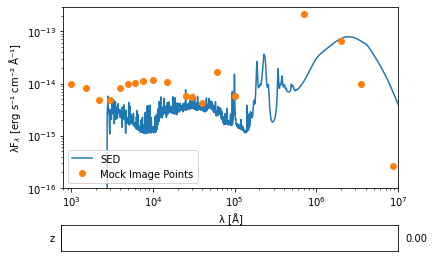

In [ ]:
# Say we have an SED and also do not know the redshift for some reason, in this case we could apply the slider
# to see what 1+z factor we need to divide the wavelength by. Therefore, we shall read in our data again
# and this time, rather than plotting in v*Fv, we will instead opt for λ*Fλ and print out the 1+z factor in the
# plot once lined up


# This will be just reading in the data again, so I will put a line where you can skip ahead to...
#SED = open("m25n512_snap160_14(2).sed", mode='r')
SED = open("m100n1024_snap078_72_ang0_dust.sed", mode='r')
linesSED = SED.readlines()

wav = np.array([]) * u.um
flux = np.array([]) * u.Jy
for i in linesSED:
    if i.split()[0] == 'Wavelength':
        skip = 0
    if i.split()[1] == '[micron]':
        skip = 0
    else:
        wav = np.append(wav, float(i.split()[0]) * u.um)
        flux = np.append(flux, float(i.split()[1]) * u.Jy)

wav = np.flip(wav)
flux = np.flip(flux)

wav = wav.to(u.AA)
flux = flux.to(u.erg/u.s/u.cm**2/u.Hz)

wavarray = np.zeros(hdu_list[0].header['NAXIS3']) * u.um
fluxarray = np.zeros(hdu_list[0].header['NAXIS3']) * u.nJy
for i in range(hdu_list[0].header['NAXIS3']):
    wavarray[i] = ((hdu_list[0].header['IWAV'+str(i)])*u.um)
    fluxarray[i] = ((np.sum(image_data[i]))*u.nJy)

wavarray = wavarray.to(u.AA)
fluxarray = fluxarray.to(u.Jy)
fluxarray = fluxarray.to(u.erg/u.s/u.cm**2/u.Hz)
fluxarray = fluxarray.to(u.erg/u.s/u.cm**2/u.AA, equivalencies=u.spectral_density(wavarray))

# ----------------------------------------------------------------------------------------------------------------

# I should warn you that this command will make a plot appear on your computer screen. To close this properly
# hit command+W on a Mac. If you use windows, this is probably be ctrl+W, but I am not entirely certain of this
%matplotlib auto

# here we will define a function in which a changing (1+z) factor will have a continuous effect
def z_factor_effect(zfactor):
    tentative_wav = wav/(1+zfactor)
    tentative_flux = flux.to(u.erg/u.s/u.cm**2/u.AA, equivalencies=u.spectral_density(tentative_wav))
    return tentative_wav, tentative_flux

# Create a plot to contain the data
ax = plt.subplot(111)

# Create a space to place your slider
plt.subplots_adjust(bottom=0.25)

# Plot your initial points
initial_z_guess = 0
SEDwav, SEDflux = z_factor_effect(initial_z_guess)[0], z_factor_effect(initial_z_guess)[1]

plt.plot(SEDwav, SEDflux*SEDwav, label='SED')
plt.plot(wavarray, fluxarray*wavarray, 'o', label='Mock Image Points')
plt.xscale("log")
plt.yscale("log")
plt.xlabel('λ [Å]')
plt.ylabel('λF$_λ$ [erg s\u207B\u00B9 cm\u207B\u00B2 Å\u207B\u00B9]')
plt.legend(loc='lower left')
plt.xlim(left=800,right=1e7)
plt.ylim(bottom=1e-16,top=3e-13)

# Create an updating function which will clear the data and plot new data accordingly as z changes
def update_z(val):
    ax.cla()   # this will clear the axis where the data is plotted
    SEDwav_new, SEDflux_new = z_factor_effect(zslider.val)[0], z_factor_effect(zslider.val)[1]
    ax.plot(SEDwav_new, SEDflux_new*SEDwav_new, label='SED')
    ax.plot(wavarray, fluxarray*wavarray, 'o', label='Mock Image Points')
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel('λ [Å]')
    ax.set_ylabel('λF$_λ$ [erg s\u207B\u00B9 cm\u207B\u00B2 Å\u207B\u00B9]')
    ax.legend(loc='lower left')
    ax.set_xlim(left=800,right=1e7)
    ax.set_ylim(bottom=1e-16,top=3e-13)
    plt.draw()

# Here we create another axis for which we will create a slider for z
ax_z = plt.axes([0.12,0.03,0.78,0.09])

# Now we create a slider using the Slider function. This entails:
# Slider('where slider goes', 'label', 'minimum value', 'max value', 'initial value')
zslider = Slider(ax_z, label='z', valmin=0., valmax=10., valinit=(initial_z_guess))

# This will ensure that everytime the slider is clicked,
# the slider itself will update as well as any values that use z
zslider.on_changed(update_z)

plt.show()

---

# References and Thanks

## A Big Thank You To:

- Dr. Kate Whitaker for guiding me along the way and giving me the instruction to make this tutorial
- Dr. Lamiya Mowla for providing and helping out with the SIMBA images and data

## References:

- [Astropy.units](https://docs.astropy.org/en/stable/units/#module-astropy.units)
- [SIMBA Website](http://simba.roe.ac.uk)
- [Davé et al. (2019)](https://arxiv.org/pdf/1901.10203.pdf)   (The SIMBA Paper)
- [AB Magnitude Wikipedia Page](https://en.wikipedia.org/wiki/AB_magnitude)
- [Kennicutt 1998](https://arxiv.org/pdf/astro-ph/9807187.pdf)
- [Speagle et al. 2014](https://arxiv.org/pdf/1405.2041.pdf)